In [1]:
%load_ext autoreload
%autoreload 2

import os, sys

# Load imports from the src directory
sys.path.insert(0, "..")

from spec.enums import MainTableColumns as Cols
import pandas as pd

In [4]:
from datasets import cs1eng, codeworkout

# Select a dataset by setting the config variable
# config = cs1eng.S24
config = codeworkout.F19


dataset_name, dataset_semester = config.name.split('_')
dataset_root_dir = os.path.join('..', '..', 'sample_data', dataset_name, dataset_semester)
dataset = config.load(dataset_root_dir)

In [5]:
# Just get the first few thousand rows for testing and quicker loading
sample_size = 10000
main_table_sample = dataset.get_main_table_head(sample_size)
# main_table_sample

In [6]:
most_common_problem = main_table_sample[Cols.ProblemID].value_counts().idxmax()
most_common_problem

np.int64(13)

In [7]:
problem_subset = main_table_sample[main_table_sample[Cols.ProblemID] == most_common_problem]
problem_subset[Cols.SubjectID].nunique()

72

In [8]:
problem_codestates = dataset.get_codestates(problem_subset[Cols.CodeStateID].unique())
problem_codestates.head()

,CodeStateID,Code
0,e03c3817ba234c667140a5281960bfc79238ef075b48c7...,"public int caughtSpeeding(int speed, boolean i..."
1,cdfe99579672f04db808aa7343826bf3c71751dfba129d...,"public int caughtSpeeding(int speed, boolean i..."
2,511eeec6958a4d834c7419dc55b4831655b13aa6d343ac...,"public int caughtSpeeding(int speed, boolean i..."
3,4c09d5ddc005e6104a8f58f76ee1020eb0adc109b13cb0...,"public int caughtSpeeding(int speed, boolean i..."
4,71514451fe4c010093a06f9f58eced6ae9de98a13edae7...,"public int caughtSpeeding(int speed, boolean i..."


In [9]:
logs_with_code = pd.merge(
    problem_subset,
    problem_codestates,
    on=Cols.CodeStateID,
)

In [10]:
from analytics.analytics_config import ProgrammingLanguage
from analytics.code.python.clean import CleanPythonPreprocessor
from spec.enums import CodeStatesTableColumns as CodeCols

if config.programming_language == ProgrammingLanguage.Python:
    cleaner = CleanPythonPreprocessor()

    cleaned_codestates = cleaner.fit_transform(logs_with_code[CodeCols.Code])
    for i in range(2):
        print(f"Original:\n{logs_with_code.iloc[i][CodeCols.Code]}")
        print(f"Cleaned:\n{cleaned_codestates[i]}")
        print()
else:
    print("No cleaner available for this programming language.")
    cleaned_codestates = logs_with_code[CodeCols.Code]

No cleaner available for this programming language.


In [11]:
from sklearn.feature_extraction.text import CountVectorizer
token_pattern = r"[\w]+|[^\s]|[ ]{4}"
ngram_range = (1,3)
vectorizer = CountVectorizer(
    lowercase=False,
    token_pattern=token_pattern,
    ngram_range=ngram_range
)

X = vectorizer.fit_transform(cleaned_codestates)
X.shape

(1809, 1392)

In [12]:
# Convert to 2D using TSNE
from sklearn.manifold import TSNE
tsne = TSNE(n_components=2)
X_tsne = tsne.fit_transform(X.toarray())
X_tsne

array([[-66.571556, -20.264671],
       [-66.571556, -20.264671],
       [-66.571556, -20.264671],
       ...,
       [ 91.984055,  35.264503],
       [ 91.984055,  35.264503],
       [ 91.984055,  35.264503]], shape=(1809, 2), dtype=float32)

<Axes: >

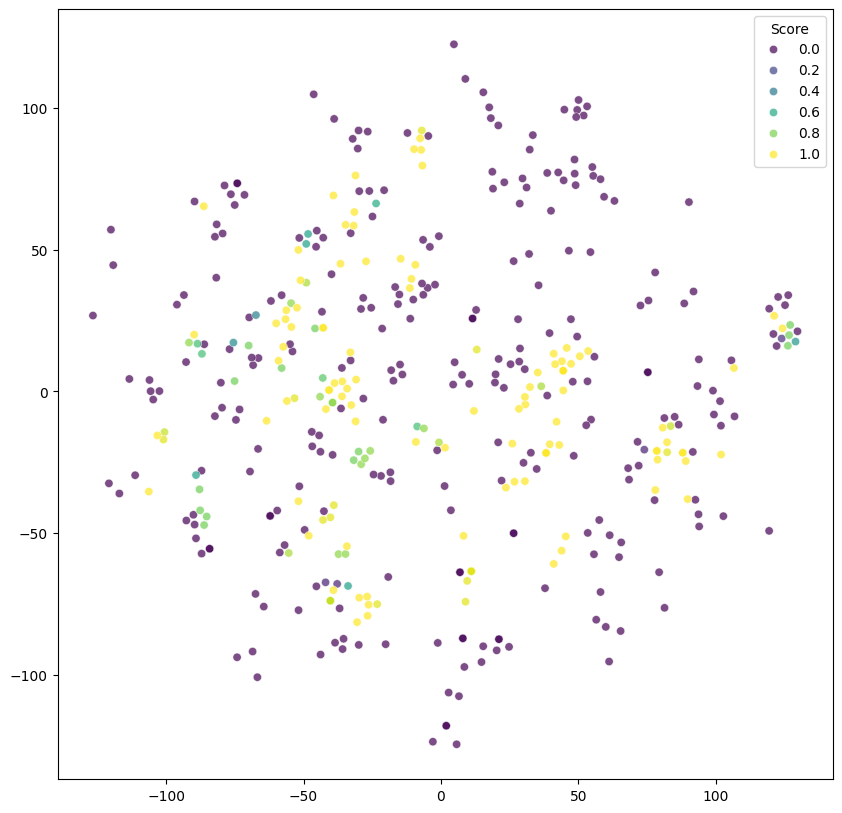

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 10))
sns.scatterplot(x=X_tsne[:,0], y=X_tsne[:,1], hue=logs_with_code[Cols.Score], palette='viridis', alpha=0.7)